# Update AnnData Object

Update various parameters of the spatial transcriptomics AnnData object.

In [4]:
# ---------------
#     Imports
# ---------------

import os.path as path
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

## Run Information

In [5]:
# Only need input directory since AnnData object is overwritten
io_dir = Path("../output/data/h5ad_objects")
train_dir = Path("../output/data/train_data_integration")

print(f"📂 Update AnnData object in: {io_dir}\n📂 Load training data from: {train_dir}")

📂 Update AnnData object in: ../output/data/h5ad_objects
📂 Load training data from: ../output/data/train_data_integration


## Load Data

In [ ]:
adata = ad.read_h5ad(io_dir / "liver_merged.h5ad")
adata

AnnData object with n_obs × n_vars = 67785 × 970
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov'
    var: 'counts_per_gene'
    layers: 'raw'

In [7]:
# Save original AnnData object
adata.write(path.join(io_dir, "original_liver_merged.h5ad"))

## Check for Redundant Data

Some of the data may be redundant and can therefore be removed, as it will not contribute to the downstream analysis.  
We especially want to compare our spatial transcriptomics genes to see if any are not included in our training data and need to be excluded.

In [ ]:
# Load training data to get list of gene names
tdata_healthy = ad.read_h5ad(
    train_dir / "healthy_mouse_liver_scRNAseq/healthy_mouse_liver_scRNAseq.h5ad",
    backed=True,
)
tdata_healthy

AnnData object with n_obs × n_vars = 389056 × 31053 backed at '../data/training_data/mouse_liver_scRNAseq_healthy.h5ad'

In [ ]:
tdata_nafld = ad.read_h5ad(
    train_dir / "NAFLD_mouse_liver_scRNAseq/NAFLD_mouse_liver_scRNAseq.h5ad",
    backed=True,
)
tdata_nafld

AnnData object with n_obs × n_vars = 256345 × 31053 backed at '../data/training_data/mouse_liver_scRNAseq_NAFLD.h5ad'

Compare the two training datasets to see if they have identical `var_names`.  
If so, comparing them to the `var_names` of the spatial transcriptomics makes sense.

In [10]:
# Get var_names from both datasets
var_names_healthy = tdata_healthy.var_names
var_names_nafld = tdata_nafld.var_names

# Compute similarity
similarity = (var_names_healthy == var_names_nafld).all()

assert similarity, "FAILURE: Gene names are not similar for scRNA-seq data!"

In [11]:
# Gene names are equal between the two training datasets
# Make all gene names upper case for better comparison
var_names_train = var_names_healthy.str.upper()
var_names_train

Index(['XKR4', 'GM1992', 'GM37381', 'RP1', 'SOX17', 'GM37323', 'MRPL15',
       'LYPLA1', 'GM37988', 'TCEA1',
       ...
       'AC125149.1', 'AC125149.2', 'AC125149.4', 'AC234645.1', 'AC168977.2',
       'AC168977.1', 'AC149090.1', 'CAAA01118383.1', 'VMN2R122',
       'CAAA01147332.1'],
      dtype='object', length=31053)

In [12]:
# Do the same for spatial transcriptomics data
var_names_st = adata.var_names.str.upper()
var_names_st

Index(['ABCA2', 'ABI1', 'ABI2', 'ABL1', 'ACE2', 'ACER3', 'ACTA2', 'ADA',
       'ADAM10', 'ADAM22',
       ...
       'NEGPRB1', 'NEGPRB2', 'NEGPRB3', 'NEGPRB4', 'NEGPRB5', 'NEGPRB6',
       'NEGPRB7', 'NEGPRB8', 'NEGPRB9', 'NEGPRB10'],
      dtype='object', length=970)

In [13]:
# Compute missing gene names
missing = set(var_names_st) - set(var_names_train)
missing

{'APH1B/C',
 'BEX1/2',
 'C1S1/2',
 'CLEC7A',
 'LILRB4A/B',
 'LYZ1/2',
 'NEGATIVEADD',
 'NEGPRB1',
 'NEGPRB10',
 'NEGPRB2',
 'NEGPRB3',
 'NEGPRB4',
 'NEGPRB5',
 'NEGPRB6',
 'NEGPRB7',
 'NEGPRB8',
 'NEGPRB9',
 'NLGN4L',
 'PRKN',
 'TUBA1A/B/C'}

List of all missing gene names in the training datasets, but which are found in our spatial transcriptomics dataset.

**Notice:** APH1B/C, "/" appears to signal that these are variants

In [14]:
"APH1B" in var_names_train

True

In [15]:
"APH1C" in var_names_train

True

Can these two entries be found in the spatial transcriptomics AnnData object?

In [16]:
adata[:, "Aph1b/c"]

View of AnnData object with n_obs × n_vars = 67785 × 1
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov'
    var: 'counts_per_gene'
    layers: 'raw'

&rarr; During creation of the spatial data these two variants can not be distinguished

Technical constraints, likely related to the fluorescence marking, prevent the correct identification of these gene variants.  
These genes must be removed from the dataset.

(Look at predicted values, can be compared later.)

Genes that are not found.  
Check for alias information on [GeneCards](https://www.genecards.org):

- CLEC7A -> No aliases match
- LILRB4B -> No aliases match
- NLGN4L -> No aliases match on NLGN4X/NLGN4Y
- PRKN -> PARK2



In [17]:
# Rename PRKN
updated = [
    "Park2" if gene_name == "Prkn" else gene_name for gene_name in adata.var_names
]
adata.var_names = updated

In [18]:
# Update missing genes list
updated_names_st = adata.var_names.str.upper()
missing = set(updated_names_st) - set(var_names_train)
missing

{'APH1B/C',
 'BEX1/2',
 'C1S1/2',
 'CLEC7A',
 'LILRB4A/B',
 'LYZ1/2',
 'NEGATIVEADD',
 'NEGPRB1',
 'NEGPRB10',
 'NEGPRB2',
 'NEGPRB3',
 'NEGPRB4',
 'NEGPRB5',
 'NEGPRB6',
 'NEGPRB7',
 'NEGPRB8',
 'NEGPRB9',
 'NLGN4L',
 'TUBA1A/B/C'}

Drop:

- Gene variants that can not be distinguished
- Negative probes (technical artifacts)

In [19]:
# Drop all missing genes
drop_mask = ~adata.var_names.str.upper().isin(missing)
adata._inplace_subset_var(drop_mask)
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov'
    var: 'counts_per_gene'
    layers: 'raw'

## Scale Values

Add layer with log scaled values.  
This method uses +1 **pseudocounts** to prevent negative values.

In [20]:
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()

In [21]:
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov'
    var: 'counts_per_gene'
    uns: 'log1p'
    layers: 'raw', 'log1p'

## Identify Highly Variable Genes

We aim to identify highly variable genes (HVGs) in our dataset, as these genes capture key biological differences across cells. Although we are particularly interested in a subset of these genes, we intentionally exclude them during model training. By masking these informative features, we can assess how well our model generalizes and performs on high-impact genes it has not seen during training.

Identify highly variable genes using the `seurat_v3` method. This approach normalizes gene variance within expression bins,
ensuring that variability is measured relative to expression level. It helps reduce bias toward highly expressed genes and is robust to technical noise.

In [22]:
# Identify highly variable genes
sc.pp.highly_variable_genes(adata, layer="raw", flavor="seurat_v3", inplace=True)

print(f"Number of HVGs: {np.sum(adata.var['highly_variable'])}")

Number of HVGs: 951


In [23]:
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'raw', 'log1p'

In [24]:
hvgs = adata.var[adata.var["highly_variable"]].copy()
hvgs

,counts_per_gene,highly_variable,highly_variable_rank,means,variances,variances_norm
Abca2,18947,True,800.0,0.279516,0.357651,0.859588
Abi1,48137,True,933.0,0.710142,1.076550,0.747721
Abi2,9686,True,537.0,0.142893,0.176147,0.945074
Abl1,16608,True,691.0,0.245010,0.317079,0.904099
Ace2,5576,True,250.0,0.082260,0.100751,1.008844
...,...,...,...,...,...,...
Il22,7209,True,480.0,0.106351,0.127321,0.958035
Il22ra1,12941,True,453.0,0.190912,0.254727,0.963450
Nos3,15339,True,444.0,0.226289,0.306620,0.964703
S100a8,20383,True,0.0,0.300701,7.744627,16.974662


In [25]:
hvgs_ranked = hvgs.sort_values("variances_norm", ascending=False)
hvgs_ranked

,counts_per_gene,highly_variable,highly_variable_rank,means,variances,variances_norm
S100a8,20383,True,0.0,0.300701,7.744627,16.974662
Spp1,38876,True,1.0,0.573519,14.942462,13.524484
Glul,302273,True,2.0,4.459290,343.189011,11.723690
Slc1a2,29089,True,3.0,0.429136,4.893011,6.808238
Ccl5,12389,True,4.0,0.182769,1.320410,5.237417
...,...,...,...,...,...,...
Fth1,2715496,True,946.0,40.060426,1287.055153,0.691767
Gnai2,98246,True,947.0,1.449377,2.767033,0.678187
Gnas,250976,True,948.0,3.702530,12.983651,0.627292
Ybx1,387080,True,949.0,5.710408,25.022709,0.534443


Select 20 HVGs that are masked during training. To ensure that important genes for prediction stay in the dataset, we take a random sample of genes between ranks 25 and 75.

In [26]:
# Selection of 50 high ranking HVGs
genes_to_select = hvgs_ranked[25:75]
genes_to_select.head(10)

,counts_per_gene,highly_variable,highly_variable_rank,means,variances,variances_norm
Ctss,56471,True,25.0,0.833090,3.607984,2.008548
Col1a2,24234,True,26.0,0.357513,1.108758,1.968731
Tyrobp,39443,True,27.0,0.581884,2.157025,1.917657
Cd55,52058,True,28.0,0.767987,3.042608,1.894061
Cd14,27521,True,29.0,0.406004,1.237716,1.874926
Lpin1,318642,True,30.0,4.700775,59.521625,1.840769
Meg3,5908,True,31.0,0.087158,0.192510,1.799143
Chrna4,25527,True,32.0,0.376588,1.013098,1.691816
Cpb2,245129,True,33.0,3.616272,32.901125,1.660138
Ccl2,10735,True,34.0,0.158368,0.346703,1.621683


In [27]:
# Choose random genes
np.random.seed(12062025)
random_selection = np.random.choice(50, size=20, replace=False)
random_selection

array([36, 29, 17, 18,  0,  4,  7, 13, 26, 24, 41, 32, 16, 37, 22, 11, 33,
       48, 42, 10])

In [28]:
# Retrieve gene entries that will be masked
genes_to_mask = genes_to_select.iloc[random_selection]

# Create mask that indicates if gene is used for testing or not
testing_mask = ~adata.var_names.isin(genes_to_mask.index)
testing_genes = adata.var_names[testing_mask]
testing_genes

Index(['Abca2', 'Abi1', 'Abi2', 'Abl1', 'Ace2', 'Acer3', 'Acta2', 'Ada',
       'Adam10', 'Adam22',
       ...
       'Ccl5', 'Cdkn1a', 'Dpp4', 'Hnf1a', 'Hnf4a', 'Il22', 'Il22ra1', 'Nos3',
       'S100a8', 'Thpo'],
      dtype='object', length=931)

In [29]:
masked_genes = adata.var_names[~testing_mask]
masked_genes

Index(['Adora1', 'Axl', 'Cd14', 'Chrna4', 'Cntn1', 'Ctss', 'Cxcl14', 'Egfr',
       'Fbln5', 'Gcgr', 'Hsp90aa1', 'Hspa1b', 'Igfbp7', 'Irs2', 'Msr1', 'Myl9',
       'Reln', 'Slc13a3', 'Timp2', 'Vim'],
      dtype='object')

In [30]:
all_genes = tdata_healthy.var_names

gene_affiliations = pd.DataFrame(
    data={
        "train_data": [gene in all_genes for gene in all_genes],
        "test_data": [gene in testing_genes for gene in all_genes],
        "masked_genes": [gene in masked_genes for gene in all_genes],
    },
    index=all_genes,
)

gene_affiliations

,train_data,test_data,masked_genes
Xkr4,True,False,False
Gm1992,True,False,False
Gm37381,True,False,False
Rp1,True,False,False
Sox17,True,False,False
...,...,...,...
AC168977.1,True,False,False
AC149090.1,True,False,False
CAAA01118383.1,True,False,False
Vmn2r122,True,False,False


In [31]:
# Save to feather format
gene_affiliations.to_feather(path.join(io_dir, "gene_affiliations.feather"))

In [34]:
# Savepoint for the AnnData object
adata.write(path.join(io_dir, "liver_merged.h5ad"))

## Update Dimensionality Reduction

In [8]:
# Reload AnnData
adata = ad.read_h5ad(path.join(io_dir, "liver_merged.h5ad"))
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    layers: 'log1p', 'raw'

Default UMAP workflow in `scanpy`:

1. PCA (UMAP works better and faster on reduced dimensions)
2. kNN (kNN in PCA space)
3. UMAP

In [9]:
# Default parameters
sc.pp.pca(adata, layer="log1p")
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/ubuntu/software/miniforge3/envs/liver-sc-imputation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


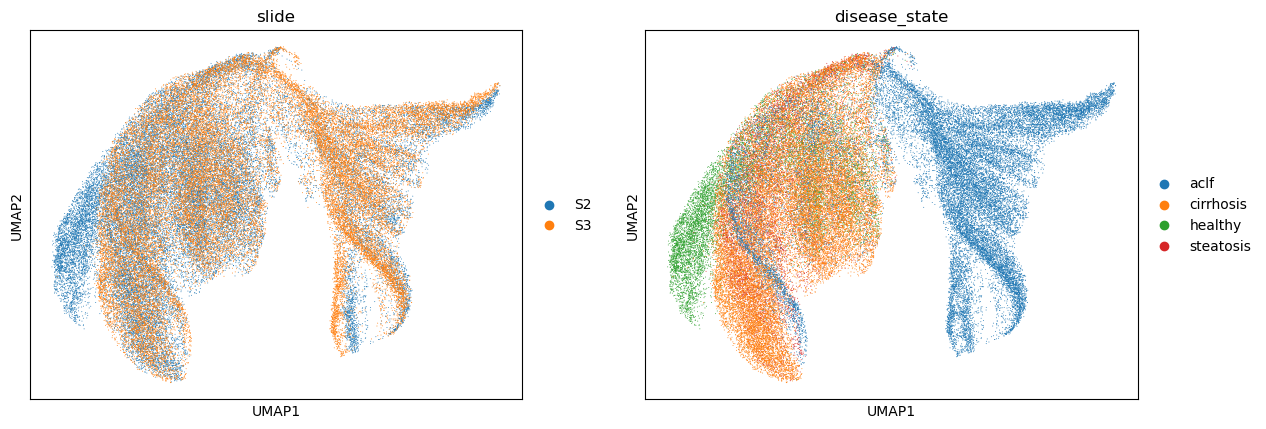

In [10]:
sc.pl.umap(adata, color=["slide", "disease_state"])

Default run.

In [13]:
sc.pp.neighbors(adata, n_neighbors=25)
sc.tl.umap(adata, min_dist=0.1)

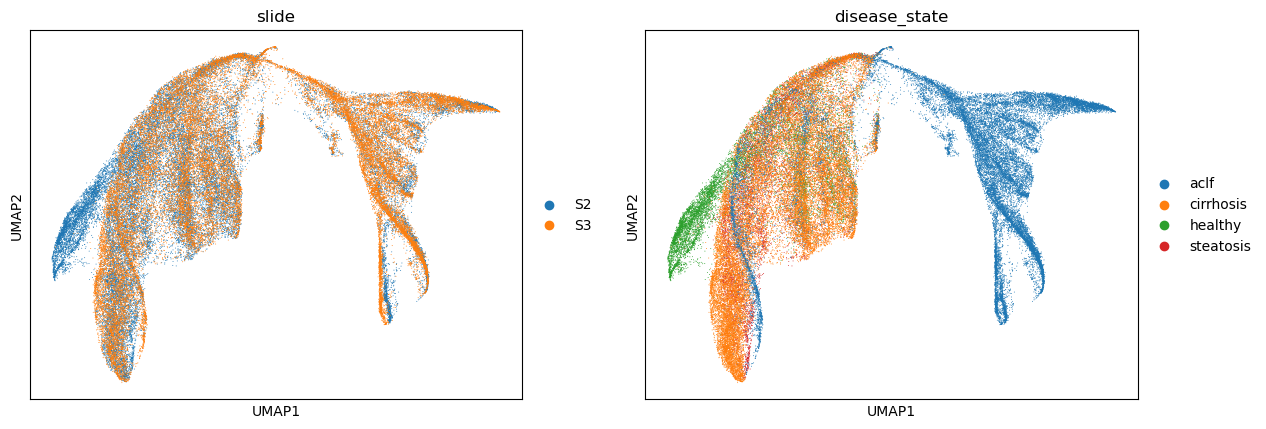

In [14]:
sc.pl.umap(adata, color=["slide", "disease_state"])

Small `min_dist` to get tight clusters.

In [15]:
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.umap(adata, min_dist=0.1)

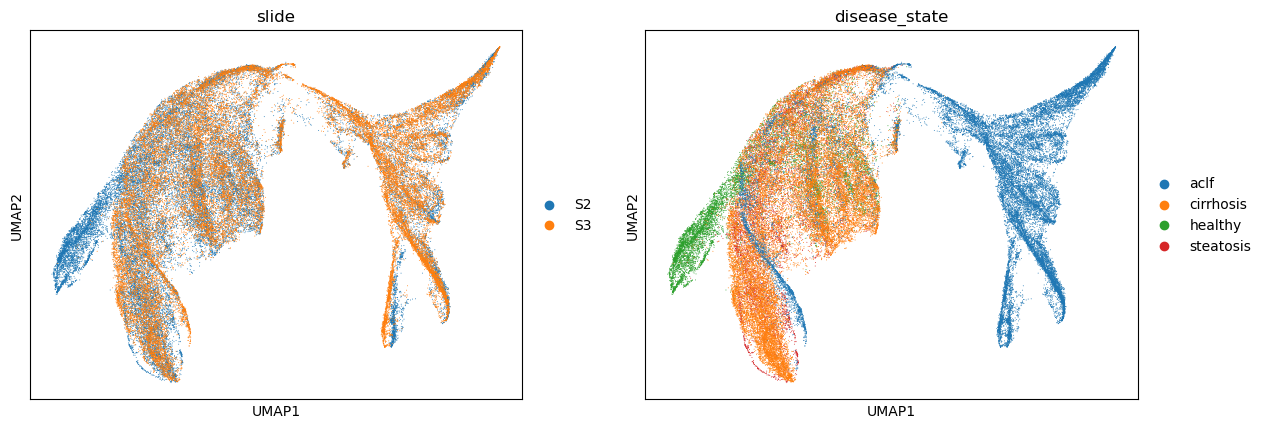

In [16]:
sc.pl.umap(adata, color=["slide", "disease_state"])

Number of neighbors appears not not have major impact.  
Will keep standard parameters.

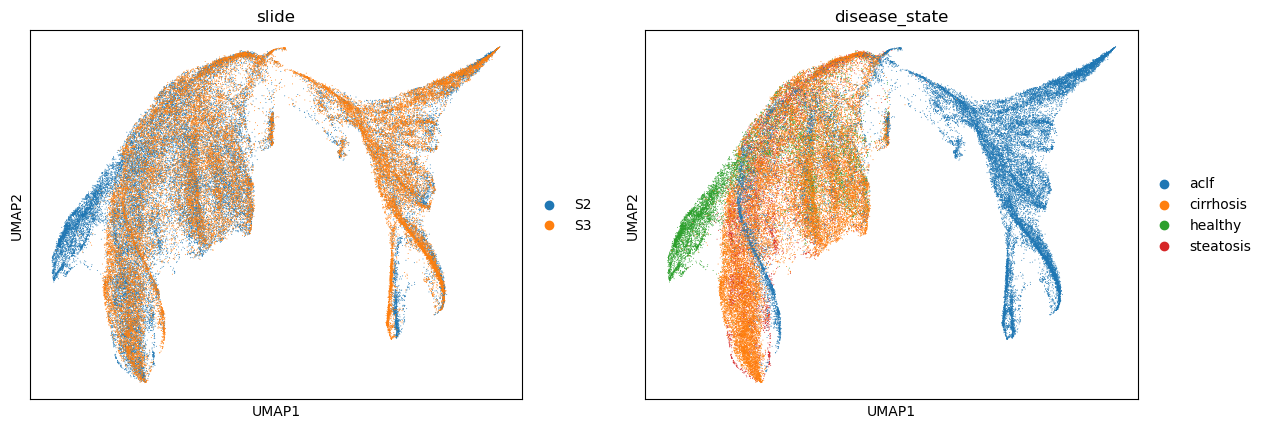

In [17]:
# Final run
sc.pp.neighbors(adata)
sc.tl.umap(adata, min_dist=0.1)

sc.pl.umap(adata, color=["slide", "disease_state"])

In [18]:
# Savepoint for the AnnData object
adata.write(io_dir / "liver_merged.h5ad", compression="gzip")

Assemble data frame to easily plot UMAPs.

In [19]:
adata

AnnData object with n_obs × n_vars = 67785 × 951
    obs: 'counts_per_cell', 'non_zero_features', 'cell_id', 'disease_state', 'slide', 'tissue', 'fov'
    var: 'counts_per_gene', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'slide_colors', 'disease_state_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log1p', 'raw'
    obsp: 'distances', 'connectivities'

In [36]:
umaps = pd.DataFrame(
    adata.obsm["X_umap"],
    columns=["umap_1", "umap_2"],
    index=adata.obs_names,
)
umaps

,umap_1,umap_2
liver1_3_1,0.167600,8.806798
liver1_4_1,-0.847367,6.216402
liver1_5_1,0.175900,6.586068
liver1_7_1,2.945525,9.352727
liver1_8_1,-0.567749,9.055143
...,...,...
liver2_531_45,0.605701,7.784894
liver2_532_45,-2.704872,4.453344
liver2_533_45,1.871059,6.471807
liver2_534_45,-1.875127,1.386655


In [28]:
obs = pd.DataFrame(
    {
        "slide": adata.obs["slide"],
        "fov": adata.obs["fov"],
        "condition": adata.obs["disease_state"],
    }
)
obs

,slide,fov,condition
liver1_3_1,S2,1_liver1,healthy
liver1_4_1,S2,1_liver1,healthy
liver1_5_1,S2,1_liver1,healthy
liver1_7_1,S2,1_liver1,healthy
liver1_8_1,S2,1_liver1,healthy
...,...,...,...
liver2_531_45,S3,45_liver2,cirrhosis
liver2_532_45,S3,45_liver2,cirrhosis
liver2_533_45,S3,45_liver2,cirrhosis
liver2_534_45,S3,45_liver2,cirrhosis


In [38]:
pdata_umaps = pd.concat([obs, umaps], axis=1)
pdata_umaps.to_feather(io_dir / "pdata_umaps_ST.feather")
pdata_umaps

,slide,fov,condition,umap_1,umap_2
liver1_3_1,S2,1_liver1,healthy,0.167600,8.806798
liver1_4_1,S2,1_liver1,healthy,-0.847367,6.216402
liver1_5_1,S2,1_liver1,healthy,0.175900,6.586068
liver1_7_1,S2,1_liver1,healthy,2.945525,9.352727
liver1_8_1,S2,1_liver1,healthy,-0.567749,9.055143
...,...,...,...,...,...
liver2_531_45,S3,45_liver2,cirrhosis,0.605701,7.784894
liver2_532_45,S3,45_liver2,cirrhosis,-2.704872,4.453344
liver2_533_45,S3,45_liver2,cirrhosis,1.871059,6.471807
liver2_534_45,S3,45_liver2,cirrhosis,-1.875127,1.386655
